# **Exercise PT - F2: Model Comparison**

## **Model A: Multinomial Logistic Regeression (MLR)**

DATA SPLIT INFORMATION


,Dataset,Instances,Percentage
0,Training Set,142,80%
1,Testing Set,36,20%



GRIDSEARCHCV RESULTS FOR MULTINOMIAL LOGISTIC REGRESSION


,C Value,Solver,Penalty,Class Weight,Mean CV Accuracy,CV Standard Deviation
0,0.001,lbfgs,l2,balanced,0.942857,0.053452
1,0.001,saga,l1,balanced,0.330000,0.056587
2,0.001,saga,l1,None,0.401429,0.030938
3,0.010,lbfgs,l2,balanced,0.964286,0.047916
4,0.010,saga,l1,balanced,0.345238,0.066573
5,0.010,saga,l1,None,0.401429,0.030938
6,0.500,lbfgs,l2,balanced,0.978571,0.045737
7,0.500,saga,l1,balanced,0.985714,0.042857
8,0.500,saga,l1,None,0.985714,0.042857
9,1.000,lbfgs,l2,balanced,0.978571,0.045737



BEST MODEL SUMMARY


,Metric,Value
0,Best C,0.5
1,Best Solver,saga
2,Best Penalty,l1
3,Best Class Weight,None
4,Best Mean CV Accuracy,0.985714
5,CV Standard Deviation,0.042857



Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36


SUMMARY TABLE


,Model,Best C,Best Solver,Best Penalty,Best Class Weight,Mean CV Acc,Test Acc,Kappa,Macro F1,Weighted F1
0,MLR,0.5,saga,l1,None,0.985714,0.972222,0.957746,0.970962,0.97197


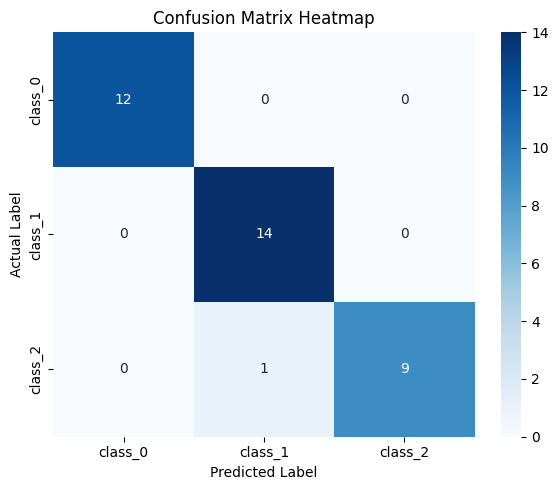

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    cohen_kappa_score
)

# Load dataset
data = load_wine()
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Data split table
split_info = pd.DataFrame({
    "Dataset": ["Training Set", "Testing Set"],
    "Instances": [X_train.shape[0], X_test.shape[0]],
    "Percentage": ["80%", "20%"]
})

print("DATA SPLIT INFORMATION")
display(split_info)

# Pipeline
pipeline_mlr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        multi_class='multinomial',
        max_iter=10000
    ))
])

# Hyperparameter grid
param_grid_mlr = [
    {
        'model__C': [0.001, 0.01, 0.50, 1, 10, 100],
        'model__solver': ['lbfgs'],
        'model__penalty': ['l2'],
        'model__class_weight': ['balanced']
    },
    {
        'model__C': [0.001, 0.01, 0.50, 1, 10, 100],
        'model__solver': ['saga'],
        'model__penalty': ['l1'],
        'model__class_weight': [None]
    },
    {
        'model__C': [0.001, 0.01, 0.50, 1, 10, 100],
        'model__solver': ['saga'],
        'model__penalty': ['l1'],
        'model__class_weight': ['balanced']
    }
]

# GridSearchCV
grid_mlr = GridSearchCV(
    estimator=pipeline_mlr,
    param_grid=param_grid_mlr,
    cv=10,
    scoring='accuracy',
    return_train_score=True
)

grid_mlr.fit(X_train, y_train)

# CV results table
cv_results = pd.DataFrame(grid_mlr.cv_results_)

cv_table = cv_results[[
    'param_model__C',
    'param_model__solver',
    'param_model__penalty',
    'param_model__class_weight',
    'mean_test_score',
    'std_test_score'
]].copy()

cv_table.columns = [
    'C Value',
    'Solver',
    'Penalty',
    'Class Weight',
    'Mean CV Accuracy',
    'CV Standard Deviation'
]

cv_table = cv_table.sort_values(by=['C Value', 'Class Weight']).reset_index(drop=True)

print("\nGRIDSEARCHCV RESULTS FOR MULTINOMIAL LOGISTIC REGRESSION")
display(cv_table)

# Best model summary
best_index = grid_mlr.best_index_

best_summary = pd.DataFrame({
    "Metric": [
        "Best C",
        "Best Solver",
        "Best Penalty",
        "Best Class Weight",
        "Best Mean CV Accuracy",
        "CV Standard Deviation"
    ],
    "Value": [
        grid_mlr.best_params_['model__C'],
        grid_mlr.best_params_['model__solver'],
        grid_mlr.best_params_['model__penalty'],
        grid_mlr.best_params_['model__class_weight'],
        grid_mlr.best_score_,
        cv_results.loc[best_index, 'std_test_score']
    ]
})

print("\nBEST MODEL SUMMARY")
display(best_summary)

# Test prediction
y_pred_mlr = grid_mlr.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred_mlr)
test_kappa = cohen_kappa_score(y_test, y_pred_mlr)

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_mlr,
    target_names=data.target_names
))

report_dict = classification_report(
    y_test,
    y_pred_mlr,
    target_names=data.target_names,
    output_dict=True
)

# Overall summary table
overall_metrics = pd.DataFrame({
    "Model": ["MLR"],
    "Best C": [grid_mlr.best_params_['model__C']],
    "Best Solver": [grid_mlr.best_params_['model__solver']],
    "Best Penalty": [grid_mlr.best_params_['model__penalty']],
    "Best Class Weight": [grid_mlr.best_params_['model__class_weight']],
    "Mean CV Acc": [grid_mlr.best_score_],
    "Test Acc": [test_accuracy],
    "Kappa": [test_kappa],
    "Macro F1": [report_dict['macro avg']['f1-score']],
    "Weighted F1": [report_dict['weighted avg']['f1-score']]
})

print("\nSUMMARY TABLE")
display(overall_metrics)

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_mlr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=data.target_names,
    yticklabels=data.target_names
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix Heatmap")

plt.tight_layout()
plt.show()

### **Library Imports**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    cohen_kappa_score
)

`import pandas as pd` - It is used to read, organize, and analyze data.

`import matplotlib.pyplot as plt` - It is used to create graphs and visualizations such as plots and charts.

`import seaborn as sns` - It is used to create more advanced and visually appealing statistical graphs like heatmaps.

`from sklearn.datasets import load_wine` - It is used to load the built-in Wine dataset for classification.

`from sklearn.model_selection import train_test_split` - It is used to split the dataset into training and testing sets.

`from sklearn.model_selection import GridSearchCV` - It is used to find the best model parameters using cross-validation.

`from sklearn.preprocessing import StandardScaler` - It is used to scale the data so that all features have similar values.

`from sklearn.pipeline import Pipeline` - It is used to combine preprocessing and modeling steps into one workflow.

`from sklearn.linear_model import LogisticRegression` - It is used as a classification model to predict categories.

`from sklearn.metrics import confusion_matrix` - It is used to show correct and incorrect predictions in a table.

`from sklearn.metrics import classification_report` - It is used to display detailed performance metrics like precision, recall, and F1-score.

`from sklearn.metrics import accuracy_score` - It is used to measure how many predictions are correct.

`from sklearn.metrics import cohen_kappa_score` - It is used to measure agreement between predicted and actual values while considering chance.

### **Load Dataset and Split Data**

In [ ]:
data = load_wine()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

split_info = pd.DataFrame({
    "Dataset": ["Training Set", "Testing Set"],
    "Instances": [X_train.shape[0], X_test.shape[0]],
    "Percentage": ["80%", "20%"]
})

print("DATA SPLIT INFORMATION")
display(split_info)

`data = load_wine()` - It loads the Wine dataset and stores it in the variable `data`.

`X = data.data` - It stores the feature values from the dataset into `X`.

`y = data.target` - It stores the target labels into `y`.

`train_test_split()` - It splits the dataset into training and testing sets (80% training, 20% testing).

`test_size=0.2` - It sets 20% of the data to be used for testing.

`random_state=42` - It ensures the data split is consistent every time the code is run.

`stratify=y` - It keeps the class distribution the same in both training and testing sets.

`pd.DataFrame()` - It creates a table to display the dataset split information.

`X_train.shape[0]` - It gets the number of rows (instances) in the training set.

`X_test.shape[0]` - It gets the number of rows (instances) in the testing set.

`print()` - It displays the title "DATA SPLIT INFORMATION".

`display()` - It shows the split information table in a clean format.

### **Build Model Pipeline and GridSearchCV**

In [ ]:
pipeline_mlr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=2000
    ))
])

param_grid_mlr = {
    'model__C': [0.001, 0.01, 0.50, 1, 10, 100, 1000, 1500, 2000, 2500, 3000]
}

grid_mlr = GridSearchCV(
    estimator=pipeline_mlr,
    param_grid=param_grid_mlr,
    cv=10,
    scoring='accuracy',
    return_train_score=True
)

`Pipeline()` - It combines multiple steps (scaling and model) into one workflow.

`StandardScaler()` - It scales the data so all features have similar values.

`LogisticRegression()` - It is the machine learning model used for classification.

`multi_class='multinomial'` - It allows the model to handle multiple classes using Softmax.

`solver='lbfgs'` - It is the algorithm used to optimize and train the model.

`max_iter=2000` - It sets the maximum number of iterations for the model to learn.

`param_grid_mlr` - It stores different values of C to test for the model.

`model__C` - It refers to the C parameter of the LogisticRegression inside the pipeline.

`GridSearchCV()` - It searches for the best parameter values using cross-validation.

`estimator=pipeline_mlr` - It uses the pipeline as the model to train.

`param_grid=param_grid_mlr` - It uses the defined C values for tuning.

`cv=10` - It performs 10-fold cross-validation.

`scoring='accuracy'` - It evaluates the model based on accuracy.

`return_train_score=True` - It also records the training scores during evaluation.

### **Train Model and Display Cross-Validation Results**

In [ ]:
grid_mlr.fit(X_train, y_train)

cv_results = pd.DataFrame(grid_mlr.cv_results_)

cv_table = cv_results[[
    'param_model__C',
    'mean_test_score',
    'std_test_score'
]].copy()

cv_table.columns = [
    'C Value',
    'Mean CV Accuracy',
    'CV Standard Deviation'
]

cv_table = cv_table.sort_values(by='C Value').reset_index(drop=True)

print("\nGRIDSEARCHCV RESULTS FOR MULTINOMIAL LOGISTIC REGRESSION")
display(cv_table)

best_index = grid_mlr.best_index_

best_summary = pd.DataFrame({
    "Metric": [
        "Best C",
        "Best Mean CV Accuracy",
        "CV Standard Deviation"
    ],
    "Value": [
        grid_mlr.best_params_['model__C'],
        grid_mlr.best_score_,
        cv_results.loc[best_index, 'std_test_score']
    ]
})

print("\nBEST MODEL SUMMARY")
display(best_summary)

`grid_mlr.fit(X_train, y_train)` - It trains the model using the training data.

`grid_mlr.cv_results_` - It stores the results of all tested parameter combinations.

`cv_results[[...]].copy()` - It selects specific columns (C value, accuracy, standard deviation) and creates a copy.

`cv_table.columns` - It renames the column headers for better readability.

`sort_values()` - It sorts the table based on the C Value.

`reset_index()` - It resets the row numbers after sorting.

`print()` - It displays the title of the results.

`display()` - It shows the cross-validation results table.

`grid_mlr.best_index_` - It gets the index of the best-performing model.

`pd.DataFrame({...})` - It creates a summary table for the best model.

`grid_mlr.best_params_['model__C']` - It retrieves the best C value found.

`grid_mlr.best_score_` - It shows the highest average accuracy from cross-validation.

`cv_results.loc[...]` - It accesses the standard deviation of the best model.

`display()` - It shows the best model summary table.

### **Test Model and Evaluate Performance**

In [ ]:
y_pred_mlr = grid_mlr.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred_mlr)
test_kappa = cohen_kappa_score(y_test, y_pred_mlr)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_mlr,
    target_names=data.target_names
))

report_dict = classification_report(
    y_test,
    y_pred_mlr,
    target_names=data.target_names,
    output_dict=True
)

overall_metrics = pd.DataFrame({
    "Model": ["MLR"],
    "Best C": [grid_mlr.best_params_['model__C']],
    "Mean CV Acc": [grid_mlr.best_score_],
    "Test Acc": [test_accuracy],
    "Kappa": [test_kappa],
    "Macro F1": [report_dict['macro avg']['f1-score']],
    "Weighted F1": [report_dict['weighted avg']['f1-score']]
})

print("\nSUMMARY TABLE")
display(overall_metrics)

`grid_mlr.predict(X_test)` - It uses the trained model to predict the labels of the test data.

`accuracy_score()` - It calculates how many predictions are correct.

`cohen_kappa_score()` - It measures how well the predictions match the actual values while considering chance.

`print()` - It displays the title "Classification Report".

`classification_report()` - It shows detailed performance metrics like precision, recall, and F1-score for each class.

`target_names=data.target_names` - It labels the classes with their actual names in the report.

`output_dict=True` - It converts the classification report into a dictionary format for further use.

`pd.DataFrame()` - It creates a summary table of the model’s performance.

`grid_mlr.best_params_['model__C']` - It retrieves the best C value from the model.

`grid_mlr.best_score_` - It shows the best cross-validation accuracy.

`report_dict['macro avg']['f1-score']` - It gets the average F1-score across all classes equally.

`report_dict['weighted avg']['f1-score']` - It gets the F1-score weighted by the number of samples per class.

`display()` - It shows the summary table in a clean format.

### **Confusion Matrix Visualization**

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred_mlr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=data.target_names,
    yticklabels=data.target_names
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix Heatmap")

plt.tight_layout()
plt.show()

`confusion_matrix()` - It creates a table showing the correct and incorrect predictions made by the model.

`plt.figure()` - It sets the size of the plot or graph.

`sns.heatmap()` - It creates a heatmap visualization of the confusion matrix.

`annot=True` - It displays the numbers inside each cell of the heatmap.

`fmt='d'` - It formats the values as integers.

`cmap='Blues'` - It sets the color theme of the heatmap to blue.

`xticklabels=data.target_names` - It labels the x-axis with the predicted class names.

`yticklabels=data.target_names` - It labels the y-axis with the actual class names.

`plt.xlabel()` - It sets the label for the x-axis.

`plt.ylabel()` - It sets the label for the y-axis.

`plt.title()` - It adds a title to the graph.

`plt.tight_layout()` - It adjusts spacing so the plot looks clean and not overlapping.

`plt.show()` - It displays the final graph.

## **Model B: Linear Support Vector Machine (Linear SVM)**


GRIDSEARCHCV RESULTS FOR LINEAR SVM


,C Value,Penalty,Loss,Dual,Class Weight,Mean CV Accuracy,CV Standard Deviation
0,0.001,l1,squared_hinge,False,None,0.330952,0.030952
1,0.010,l1,squared_hinge,False,None,0.957143,0.047380
2,0.500,l1,squared_hinge,False,None,0.985714,0.042857
3,1.000,l1,squared_hinge,False,None,0.978571,0.045737
4,10.000,l1,squared_hinge,False,None,0.985714,0.028571
5,100.000,l1,squared_hinge,False,None,0.985714,0.028571
6,0.001,l2,hinge,True,balanced,0.936190,0.049952
7,0.010,l2,hinge,True,balanced,0.964286,0.047916
8,0.500,l2,hinge,True,balanced,0.971429,0.047380
9,1.000,l2,hinge,True,balanced,0.978571,0.032733



BEST MODEL SUMMARY (SVM)


,Metric,Value
0,Best C,0.01
1,Best Penalty,l2
2,Best Loss,squared_hinge
3,Best Dual,False
4,Best Class Weight,None
5,Best Mean CV Accuracy,0.985714
6,CV Standard Deviation,0.028571



Classification Report (SVM):
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


SUMMARY TABLE (SVM)


,Model,Best C,Best Penalty,Best Loss,Best Dual,Best Class Weight,Mean CV Acc,Test Acc,Kappa,Macro F1,Weighted F1
0,Linear SVM,0.01,l2,squared_hinge,False,None,0.985714,1.0,1.0,1.0,1.0


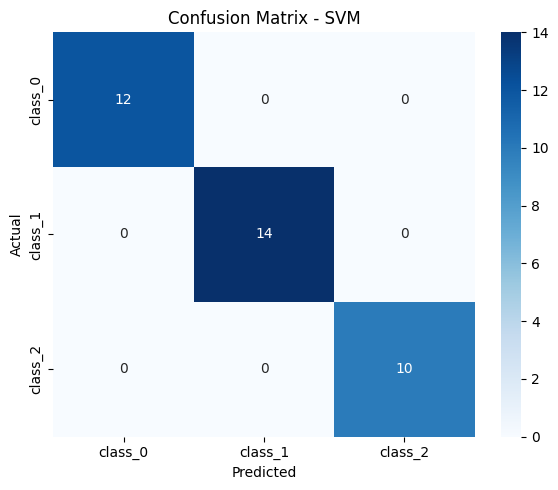

In [ ]:
from sklearn.svm import LinearSVC

pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearSVC(max_iter=10000))
])

param_grid_svm = [
    {
        'model__C': [0.001, 0.01, 0.50, 1, 10, 100],
        'model__penalty': ['l2'],
        'model__loss': ['squared_hinge'],
        'model__dual': [False],
        'model__class_weight': [None]
    },
    {
        'model__C': [0.001, 0.01, 0.50, 1, 10, 100],
        'model__penalty': ['l2'],
        'model__loss': ['hinge'],
        'model__dual': [True],
        'model__class_weight': ['balanced']
    },
    {
        'model__C': [0.001, 0.01, 0.50, 1, 10, 100],
        'model__penalty': ['l1'],
        'model__loss': ['squared_hinge'],
        'model__dual': [False],
        'model__class_weight': [None]
    }
]

grid_svm = GridSearchCV(
    estimator=pipeline_svm,
    param_grid=param_grid_svm,
    cv=10,
    scoring='accuracy',
    return_train_score=True
)

grid_svm.fit(X_train, y_train)

# CV results
svm_cv_results = pd.DataFrame(grid_svm.cv_results_)

svm_cv_table = svm_cv_results[[
    'param_model__C',
    'param_model__penalty',
    'param_model__loss',
    'param_model__dual',
    'param_model__class_weight',
    'mean_test_score',
    'std_test_score'
]].copy()

svm_cv_table.columns = [
    'C Value',
    'Penalty',
    'Loss',
    'Dual',
    'Class Weight',
    'Mean CV Accuracy',
    'CV Standard Deviation'
]

svm_cv_table['Class Weight'] = svm_cv_table['Class Weight'].astype(str)

svm_cv_table = svm_cv_table.sort_values(
    by=['Penalty', 'Loss', 'Class Weight', 'C Value']
).reset_index(drop=True)

print("\nGRIDSEARCHCV RESULTS FOR LINEAR SVM")
display(svm_cv_table)

# Best model
svm_best_index = grid_svm.best_index_

svm_best_summary = pd.DataFrame({
    "Metric": [
        "Best C",
        "Best Penalty",
        "Best Loss",
        "Best Dual",
        "Best Class Weight",
        "Best Mean CV Accuracy",
        "CV Standard Deviation"
    ],
    "Value": [
        grid_svm.best_params_['model__C'],
        grid_svm.best_params_['model__penalty'],
        grid_svm.best_params_['model__loss'],
        grid_svm.best_params_['model__dual'],
        grid_svm.best_params_['model__class_weight'],
        grid_svm.best_score_,
        svm_cv_results.loc[svm_best_index, 'std_test_score']
    ]
})

print("\nBEST MODEL SUMMARY (SVM)")
display(svm_best_summary)

# Prediction
y_pred_svm = grid_svm.predict(X_test)

# Final test metrics
svm_test_accuracy = accuracy_score(y_test, y_pred_svm)
svm_test_kappa = cohen_kappa_score(y_test, y_pred_svm)

print("\nClassification Report (SVM):")
print(classification_report(
    y_test,
    y_pred_svm,
    target_names=data.target_names
))

svm_report_dict = classification_report(
    y_test,
    y_pred_svm,
    target_names=data.target_names,
    output_dict=True
)

# Summary
svm_summary = pd.DataFrame({
    "Model": ["Linear SVM"],
    "Best C": [grid_svm.best_params_['model__C']],
    "Best Penalty": [grid_svm.best_params_['model__penalty']],
    "Best Loss": [grid_svm.best_params_['model__loss']],
    "Best Dual": [grid_svm.best_params_['model__dual']],
    "Best Class Weight": [grid_svm.best_params_['model__class_weight']],
    "Mean CV Acc": [grid_svm.best_score_],
    "Test Acc": [svm_test_accuracy],
    "Kappa": [svm_test_kappa],
    "Macro F1": [svm_report_dict['macro avg']['f1-score']],
    "Weighted F1": [svm_report_dict['weighted avg']['f1-score']]
})

print("\nSUMMARY TABLE (SVM)")
display(svm_summary)

# Confusion Matrix
svm_conf_matrix = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    svm_conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=data.target_names,
    yticklabels=data.target_names
)

plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### **Library Import (SVM)**

In [ ]:
from sklearn.svm import LinearSVC

`LinearSVC()` - It is a linear Support Vector Machine model used for classification.

### **Build Model Pipeline and GridSearchCV (SVM)**

In [ ]:
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearSVC(max_iter=2000))
])

param_grid_svm = {
    'model__C': [0.001, 0.01, 0.50, 1, 10, 100, 1000, 1500, 2000, 2500, 3000]
}

grid_svm = GridSearchCV(
    estimator=pipeline_svm,
    param_grid=param_grid_svm,
    cv=10,
    scoring='accuracy',
    return_train_score=True
)

`Pipeline()` - It combines scaling and the model into one workflow.

`StandardScaler()` - It scales the data so all features have similar values.

`max_iter=2000` - It sets the maximum number of iterations for the SVM model to train.

`param_grid_svm` - It stores different values of C to test for the SVM model.

`model__C` - It refers to the C parameter of the LinearSVC inside the pipeline.

`GridSearchCV()` - It searches for the best C value using cross-validation.

`cv=10` - It performs 10-fold cross-validation.

`scoring='accuracy'` - It evaluates the model based on accuracy.


### **Train Model and Display Cross-Validation Results**

In [ ]:
grid_svm.fit(X_train, y_train)

svm_cv_results = pd.DataFrame(grid_svm.cv_results_)

svm_cv_table = svm_cv_results[[
    'param_model__C',
    'mean_test_score',
    'std_test_score'
]].copy()

svm_cv_table.columns = [
    'C Value',
    'Mean CV Accuracy',
    'CV Standard Deviation'
]

svm_cv_table = svm_cv_table.sort_values(by='C Value').reset_index(drop=True)

print("\nGRIDSEARCHCV RESULTS FOR LINEAR SVM")
display(svm_cv_table)

svm_best_index = grid_svm.best_index_

svm_best_summary = pd.DataFrame({
    "Metric": [
        "Best C",
        "Best Mean CV Accuracy",
        "CV Standard Deviation"
    ],
    "Value": [
        grid_svm.best_params_['model__C'],
        grid_svm.best_score_,
        svm_cv_results.loc[svm_best_index, 'std_test_score']
    ]
})

print("\nBEST MODEL SUMMARY (SVM)")
display(svm_best_summary)

`grid_svm.fit()` - It trains the SVM model using the training data.

`pd.DataFrame()` - It converts the cross-validation results into a table.

`svm_cv_results[[...]].copy()` - It selects important columns and creates a copy.

`sort_values()` - It sorts the results based on the C value.

`reset_index()` - It resets the row numbers after sorting.

`grid_svm.best_index_` - It gets the index of the best-performing model.

`grid_svm.best_params_['model__C']` - It retrieves the best C value.

`grid_svm.best_score_` - It shows the best cross-validation accuracy.


### **Test Model and Evaluate Performance**

In [ ]:
y_pred_svm = grid_svm.predict(X_test)

svm_test_accuracy = accuracy_score(y_test, y_pred_svm)
svm_test_kappa = cohen_kappa_score(y_test, y_pred_svm)

print("\nClassification Report (SVM):")
print(classification_report(
    y_test,
    y_pred_svm,
    target_names=data.target_names
))

svm_report_dict = classification_report(
    y_test,
    y_pred_svm,
    target_names=data.target_names,
    output_dict=True
)

svm_summary = pd.DataFrame({
    "Model": ["Linear SVM"],
    "Best C": [grid_svm.best_params_['model__C']],
    "Mean CV Acc": [grid_svm.best_score_],
    "Test Acc": [svm_test_accuracy],
    "Kappa": [svm_test_kappa],
    "Macro F1": [svm_report_dict['macro avg']['f1-score']],
    "Weighted F1": [svm_report_dict['weighted avg']['f1-score']]
})

print("\nSUMMARY TABLE (SVM)")
display(svm_summary)

`grid_svm.predict()` - It predicts the labels of the test data.

`accuracy_score()` - It calculates how many predictions are correct.

`cohen_kappa_score()` - It measures agreement between predicted and actual values.

`classification_report()` - It shows detailed metrics like precision, recall, and F1-score.

`output_dict=True` - It converts the report into a dictionary format.

`pd.DataFrame()` - It creates the summary table of results.

### **Confusion Matrix Visualization**

In [ ]:
svm_conf_matrix = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    svm_conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=data.target_names,
    yticklabels=data.target_names
)

plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

`confusion_matrix()` - It creates a table of correct and incorrect predictions.

`plt.figure()` - It sets the size of the plot.

`sns.heatmap()` - It visualizes the confusion matrix as a heatmap.

`annot=True` - It shows values inside the heatmap.

`fmt='d'` - It formats values as integers.

`cmap='Blues'` - It sets the color theme.

`plt.title()` - It adds a title to the graph.

`plt.xlabel()` - It labels the x-axis.

`plt.ylabel()` - It labels the y-axis.

`plt.tight_layout()` - It adjusts spacing for better layout.

`plt.show()` - It displays the graph.

## **Feature Importance**

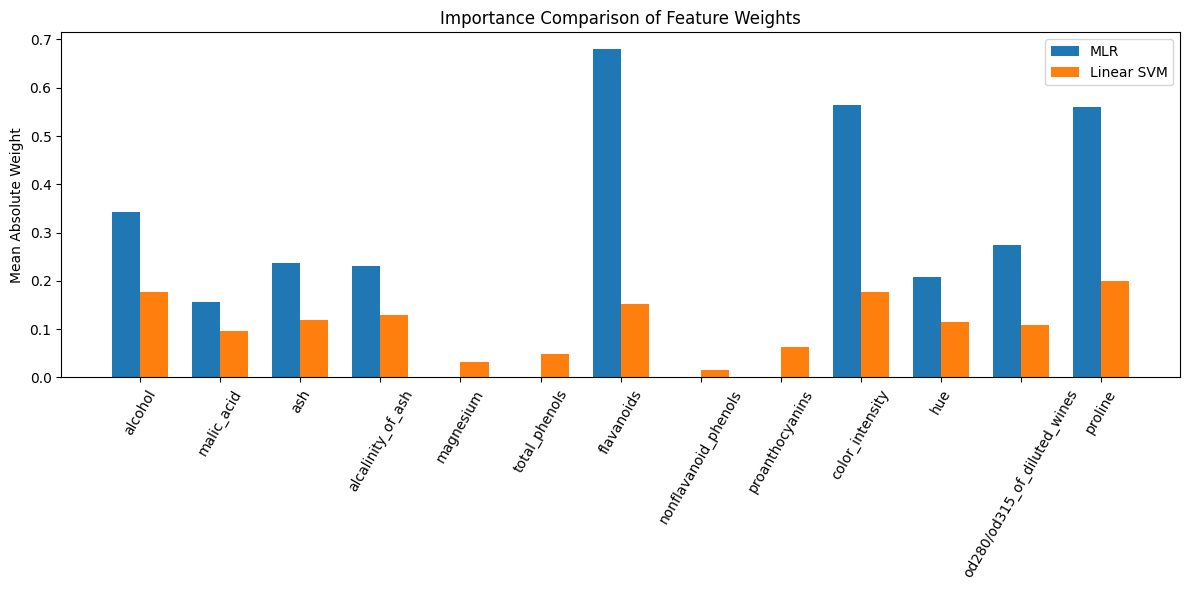

In [ ]:
import numpy as np

# FEATURE IMPORTANCE (COEFFICIENTS)

# Get trained models from pipeline
mlr_model = grid_mlr.best_estimator_.named_steps['model']
svm_model = grid_svm.best_estimator_.named_steps['model']

# Compute mean absolute coefficients (for multiclass)
mlr_importance = np.mean(np.abs(mlr_model.coef_), axis=0)
svm_importance = np.mean(np.abs(svm_model.coef_), axis=0)

# Feature names
features = data.feature_names

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': features,
    'MLR': mlr_importance,
    'Linear SVM': svm_importance
})

# PLOT FEATURE IMPORTANCE
x = np.arange(len(features))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(x - width/2, importance_df['MLR'], width, label='MLR')
plt.bar(x + width/2, importance_df['Linear SVM'], width, label='Linear SVM')

plt.xticks(x, features, rotation=60)
plt.ylabel("Mean Absolute Weight")
plt.title("Importance Comparison of Feature Weights")
plt.legend()

plt.tight_layout()
plt.show()